In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
import datageneration

In [1]:
import numpy as np

def generate_data(gen_dat):
    n = gen_dat["n"]
    p = gen_dat["p"]
    k = gen_dat["k"]
    alpha = gen_dat["alpha"]
    beta_star = gen_dat["beta_star"]
    dat_type = gen_dat["dat_type"]
    if dat_type == 1:
        # set initial value
        X = np.zeros((n, p))
        beta = np.zeros((p, 1))
        itrue = np.array(range(k)) * 10
        beta[itrue] = beta_star            
        # generate data
        
        for i in range(n):
            Xtemp = np.random.randn(1, p)
            z = np.random.randn()
            Xtemp = alpha * z + Xtemp
            X[i] = Xtemp
        
        Y = X.dot(beta)
        Y = Y.T + np.random.randn(1, n)
        return(X, Y.T, beta, itrue)
    
    elif dat_type == 2:
        #set initial value
        delta = 0.9  ## 0.5 have a better result
        sigma_mat = np.zeros((p, p))
        for i in range(p):
            for j in range(p):
                sigma_mat[i, j] = delta**abs(i-j)
        # decomposition
        eig_vector, V = np.linalg.eig(sigma_mat)
        sigma_mat_sqrt = V.dot(np.diag(np.sqrt(eig_vector))).dot(V.T)
        ##
        ## Generate X
        ##
        X = np.random.randn(n, p)
        X = X.dot(sigma_mat_sqrt)
        ##
        beta = np.zeros((p, 1))
        itrue = np.arange(k) * 10
        beta[itrue] = beta_star
        ## Generate Y
        Y = X.dot(beta)
        Y = Y.T + np.random.randn(1, n)
        return(X, Y.T, beta, itrue)

In [2]:
gen_data = {"n":1000, "p":1000, "k":100, "alpha":1, "beta_star":1, "dat_type":1}


In [ ]:
import matplotlib.pyplot as plt
def scatter_plot(X, Y):
    x_vals = X[:, 0]          # shape (n,)
    y_vals = Y.ravel()        # Y 是 (n,1) -> 拉平成 (n,)


    a, b = np.polyfit(x_vals, y_vals, deg=1)   # a: 斜率, b: 截距

    # 为了画直线，按照 x 的范围生成一组有序点
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_line = a * x_line + b

    # 绘制散点图
    plt.figure(figsize=(6, 4))
    plt.scatter(x_vals, y_vals, s=10, alpha=0.6)
    
    # 绘制拟合直线
    plt.plot(x_line, y_line, 'r-', linewidth=2, label=f"fit: y = {a:.2f}x + {b:.2f}")

    plt.xlabel("X[:, 0]")
    plt.ylabel("Y")
    plt.title("Scatter plot of Y vs X[:, 0]")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


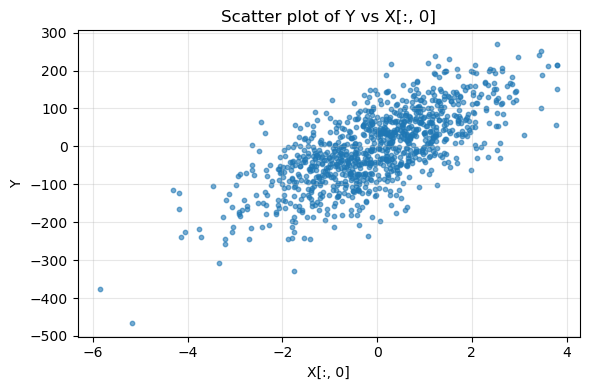

In [8]:
X, Y, beta, itrue = generate_data(gen_data)
scatter_plot(X, Y)

In [104]:
def plot_metric_vs_n(
    df: pd.DataFrame,
    metric_col: str,
    title: str,
    ylabel: str,
    save_path: str = None,
):
    """
    在不同 n 下，画某个 metric 的曲线：
    - 横轴: n
    - 纵轴: metric_col
    - 不同 method / beta_star 画成不同曲线
    """
    if "n" not in df.columns:
        raise ValueError("DataFrame 中缺少列 'n'")
    if metric_col not in df.columns:
        raise ValueError(f"DataFrame 中缺少列 '{metric_col}'")

    plt.figure(figsize=(6, 4))

    # 按 method 和 beta_star 分组，分别画曲线
    group_cols = ["method"]
    if "beta_star" in df.columns:
        group_cols.append("beta_star")

    for keys, sub in df.groupby(group_cols):
        sub = sub.sort_values("n")

        # 组名 -> legend 标签
        if isinstance(keys, tuple):
            method = keys[0]
            beta = keys[1] if len(keys) > 1 else None
        else:
            method = keys
            beta = None

        if beta is not None:
            label = f"{method}, β*={beta}"
        else:
            label = f"{method}"

        plt.plot(
            sub["n"],
            sub[metric_col],
            marker="o",
            linewidth=1.8,
            markersize=4,
            label=label,
        )

    plt.xlabel("n (sample size)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3, linestyle="--")
    plt.legend(fontsize=8)
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300)
        print(f"[PLOT] Saved figure to: {save_path}")

    plt.show()


def add_true_recovery_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    在 df 上增加一列 'TrueRecoveryRate':
      TrueRecoveryRate = DR / loop_time
    其中 DR 是 perfectly recovered 的次数，loop_time 是重复实验次数。
    """
    df = df.copy()
    if "DR" not in df.columns or "loop_time" not in df.columns:
        raise ValueError("DataFrame 中缺少 'DR' 或 'loop_time' 列")

    df["TrueRecoveryRate"] = df["DR"] / df["loop_time"].astype(float)
    return df


In [105]:
load_dir = './results'
# if not os.path.exists(load_dir):
#     os.makedirs(load_dir)

load_file = os.path.join(load_dir, "grid_results_onlineFSA_and_Lasso.csv")
# for online methods
df_all = pd.read_csv(load_file)


# ===== 画 Detection Rate (PCD) 和 True-Recovery 的曲线 =====
# Detection Rate 用 summarize_result_mat 里的 PCD（比例正确发现）
# True-RecoveryRate 用 DR / loop_time

df_all_plot = add_true_recovery_column(df_all)


# for offline methods

# print(df_all.head(1))


### For online methods

[PLOT] Saved figure to: ./plots/PCD_vs_n_online_reg.png


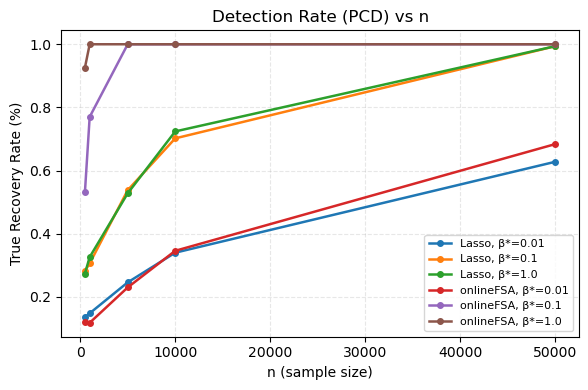

In [ ]:
save_dir = './plots'
# 1) Detection Rate (PCD) vs n
pcd_fig = os.path.join(save_dir, "PCD_vs_n_online_reg.png")
plot_metric_vs_n(
    df=df_all_plot,
    metric_col="PCD",
    title="Detection Rate (PCD) vs n",
    ylabel="True Recovery Rate",
    save_path=pcd_fig,
)

[PLOT] Saved figure to: ./plots/TrueRecovery_vs_n_online_reg.png


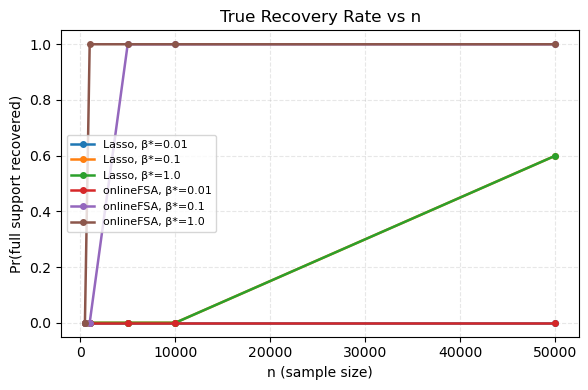

In [5]:
# 2) True-Recovery Rate vs n
tr_fig = os.path.join(save_dir, "TrueRecovery_vs_n_online_reg.png")
plot_metric_vs_n(
    df=df_all_plot,
    metric_col="TrueRecoveryRate",
    title="True Recovery Rate vs n",
    ylabel="Pr(full support recovered)",
    save_path=tr_fig,
)

### Compare RMSE in different n samples

In [94]:
import numpy as np

# online results: df_all
# ffline 


# ===== 2. 一个通用的聚合函数：按 (method, n) 统计 RMSE 的均值和标准差 =====
def agg_val_by_method_n(df: pd.DataFrame, col_name="RMSE") -> pd.DataFrame:
    # 兼容列名：优先用 col_name_mean，如果没有就用 col_name
    if col_name + "_mean" in df.columns:
        rmse_col = col_name + "_mean"
    elif col_name in df.columns:
        rmse_col = col_name
    else:
        raise ValueError(f"找不到 {col_name} 列，请检查列名（应为 '{col_name}_mean' 或 '{col_name}'）")

    # 如果没有 method 列（理论上你现在三个文件都有），可以手动补一个
    if "method" not in df.columns:
        raise ValueError("DataFrame 中缺少 'method' 列")

    g = (
        df
        .groupby(["method", "n"], as_index=False)[rmse_col]
        .agg(["mean", "std"])
        .reset_index()
    )
    g.rename(columns={"mean": col_name + "_mean", "std": col_name + "_std"}, inplace=True)
    return g


# ===== 3. 画图辅助函数 =====
def plot_metric_vs_n(df_list, methods, title, xlabel="n", ylabel="RMSE", save_dir=None):
    """
    df_list: [df1, df2, ...]，每个 df 必须有列: method, n, rmse_mean, rmse_std
    methods: 要画的 method 名称列表，例如 ["onlineFSA", "offlineFSA"]
    """
    # 先拼起来，方便统一过滤
    df_all = pd.concat(df_list, ignore_index=True)

    plt.figure(figsize=(6, 4))
    for m in methods:
        sub = df_all[df_all["method"] == m].copy()
        if sub.empty:
            print(f"[WARN] method={m} 没有数据，跳过")
            continue
        sub = sub.sort_values("n")

        plt.errorbar(
            sub["n"],
            sub[f"{ylabel}_mean"],
            yerr=sub[f"{ylabel}_std"],
            marker="o",
            capsize=3,
            label=m,
        )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(os.path.join(save_dir, title.replace(" ", "_") + ".png"), dpi=300)

    plt.show()


In [7]:
load_offline_fsa = os.path.join(load_dir, "offlineFSA_grid.csv")
# for online methods
df_off_fsa = pd.read_csv(load_offline_fsa)

load_offline_lasso = os.path.join(load_dir, "offlineLasso_grid.csv")
# for online methods
df_off_lasso = pd.read_csv(load_offline_lasso)

df_off_fsa = df_off_fsa[df_off_fsa["n"] != 100000].copy()
df_off_lasso = df_off_lasso[df_off_lasso["n"] != 100000].copy()

g_online = agg_val_by_method_n(df_all, col_name="RMSE")  # 含 onlineFSA, Lasso 两种 method
g_offF   = agg_val_by_method_n(df_off_fsa, col_name="RMSE")    # offlineFSA
g_offL   = agg_val_by_method_n(df_off_lasso, col_name="RMSE")    # offlineLasso

In [24]:
g_online_time = agg_val_by_method_n(df_all, col_name="Runtime")  # 含 onlineFSA, Lasso 两种 method
g_offF_time   = agg_val_by_method_n(df_off_fsa, col_name="Runtime")    # offlineFSA
g_offL_time   = agg_val_by_method_n(df_off_lasso, col_name="Runtime")    # offlineLasso

In [9]:
g_online

,index,method,n,RMSE_mean,RMSE_std
0,0,Lasso,500,5.208648,6.561941
1,1,Lasso,1000,4.799942,5.981353
2,2,Lasso,5000,3.618346,4.271679
3,3,Lasso,10000,2.782751,2.920669
4,4,Lasso,50000,1.097957,0.144008
5,5,onlineFSA,500,1.983975,1.161177
6,6,onlineFSA,1000,1.149759,0.082750
7,7,onlineFSA,5000,1.013129,0.016780
8,8,onlineFSA,10000,1.012174,0.002002
9,9,onlineFSA,50000,0.989692,0.001664


In [10]:
g_offF

,index,method,n,RMSE_mean,RMSE_std
0,0,offlineFSA,500,1.983975,1.161177
1,1,offlineFSA,1000,1.149759,0.082750
2,2,offlineFSA,5000,1.016596,0.012954
3,3,offlineFSA,10000,1.012160,0.000296
4,4,offlineFSA,50000,0.988600,0.001123


In [11]:
g_online_time

,index,method,n,Runtime_mean,Runtime_std
0,0,Lasso,500,28.109611,5.490711
1,1,Lasso,1000,34.931410,4.950616
2,2,Lasso,5000,49.405042,7.639092
3,3,Lasso,10000,81.626036,3.155218
4,4,Lasso,50000,5027.714072,3083.990086
5,5,onlineFSA,500,2.440016,0.013238
6,6,onlineFSA,1000,2.456538,0.000428
7,7,onlineFSA,5000,4.209179,0.820865
8,8,onlineFSA,10000,4.437578,1.171012
9,9,onlineFSA,50000,3.737026,0.023878


In [12]:
g_offF_time

,index,method,n,Runtime_mean,Runtime_std
0,0,offlineFSA,500,2.497726,0.048703
1,1,offlineFSA,1000,2.457164,0.000404
2,2,offlineFSA,5000,2.472658,0.049979
3,3,offlineFSA,10000,3.631010,2.056531
4,4,offlineFSA,50000,3.729752,0.013395


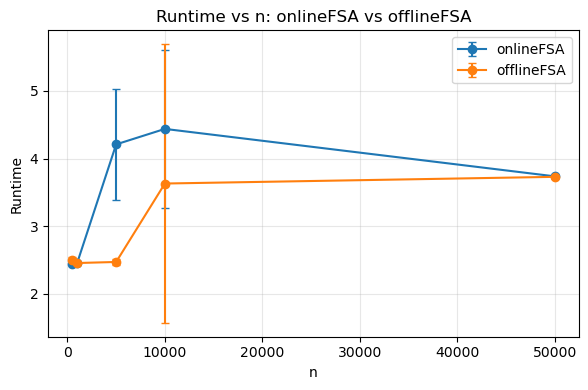

In [13]:
# ===== 4. 画两张对比图 =====

# 4.1 onlineFSA vs offlineFSA
plot_metric_vs_n(
    df_list=[g_online_time, g_offF_time],
    methods=["onlineFSA", "offlineFSA"],
    title="Runtime vs n: onlineFSA vs offlineFSA",
    ylabel="Runtime",
    save_dir=save_dir,
)

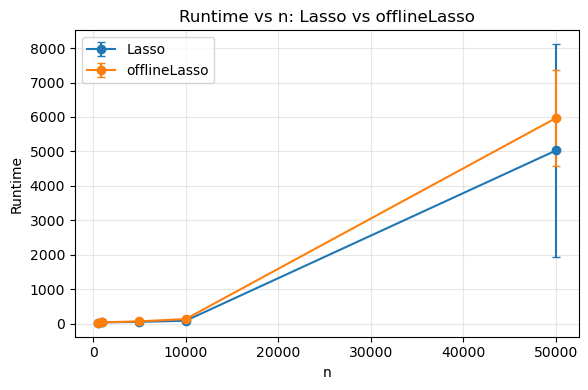

In [14]:
# 4.2 Lasso vs offlineLasso
plot_metric_vs_n(
    df_list=[g_online_time, g_offL_time],
    methods=["Lasso", "offlineLasso"],
    title="Runtime vs n: Lasso vs offlineLasso",
    ylabel="Runtime",
    save_dir=save_dir,
)

In [15]:
df_all.head(3)

,method,n,p,k,alpha,beta_star,dat_type,hp_eta,hp_lbd,loop_time,DR,PCD,RMSE_mean,Runtime_mean,wall_time,hp_lbd_para
0,onlineFSA,500,1000,100,1,1.00,1,0.01,0.0,5,0,0.926,3.322377,2.432838,0.522725,NaN
1,onlineFSA,500,1000,100,1,0.10,1,0.01,0.0,5,0,0.532,1.384358,2.431916,0.527171,NaN
2,onlineFSA,500,1000,100,1,0.01,1,0.01,0.0,5,0,0.120,1.245191,2.455293,0.517844,NaN


### Detection Rate

In [16]:
g_online_pcd = agg_val_by_method_n(df_all, col_name="PCD")
g_online_pcd

,index,method,n,PCD_mean,PCD_std
0,0,Lasso,500,0.230667,0.082081
1,1,Lasso,1000,0.260000,0.097509
2,2,Lasso,5000,0.437333,0.165775
3,3,Lasso,10000,0.588667,0.215632
4,4,Lasso,50000,0.872000,0.211310
5,5,onlineFSA,500,0.526000,0.403033
6,6,onlineFSA,1000,0.629333,0.457516
7,7,onlineFSA,5000,0.743333,0.444560
8,8,onlineFSA,10000,0.782000,0.377587
9,9,onlineFSA,50000,0.894667,0.182443


In [17]:
df_off_lasso_pcd = agg_val_by_method_n(df_off_lasso, col_name="PCD_mean")
df_off_lasso_pcd

,index,method,n,PCD_mean_mean,PCD_mean_std
0,0,offlineLasso,500,0.230667,0.082081
1,1,offlineLasso,1000,0.260000,0.097509
2,2,offlineLasso,5000,0.437333,0.165775
3,3,offlineLasso,10000,0.588667,0.215632
4,4,offlineLasso,50000,0.872000,0.211310


In [18]:
df_off_fsa_pcd = agg_val_by_method_n(df_off_fsa, col_name="PCD_mean")
df_off_fsa_pcd

,index,method,n,PCD_mean_mean,PCD_mean_std
0,0,offlineFSA,500,0.526000,0.403033
1,1,offlineFSA,1000,0.629333,0.457516
2,2,offlineFSA,5000,0.741333,0.446293
3,3,offlineFSA,10000,0.781333,0.378742
4,4,offlineFSA,50000,0.895333,0.181288


### RMSE

In [19]:
g_online_rmse = agg_val_by_method_n(df_all, col_name="RMSE_mean")
g_online_rmse

,index,method,n,RMSE_mean_mean,RMSE_mean_std
0,0,Lasso,500,5.208648,6.561941
1,1,Lasso,1000,4.799942,5.981353
2,2,Lasso,5000,3.618346,4.271679
3,3,Lasso,10000,2.782751,2.920669
4,4,Lasso,50000,1.097957,0.144008
5,5,onlineFSA,500,1.983975,1.161177
6,6,onlineFSA,1000,1.149759,0.082750
7,7,onlineFSA,5000,1.013129,0.016780
8,8,onlineFSA,10000,1.012174,0.002002
9,9,onlineFSA,50000,0.989692,0.001664


In [20]:
df_off_fsa_rmse = agg_val_by_method_n(df_off_fsa, col_name="RMSE_mean")
df_off_fsa_rmse

,index,method,n,RMSE_mean_mean,RMSE_mean_std
0,0,offlineFSA,500,1.983975,1.161177
1,1,offlineFSA,1000,1.149759,0.082750
2,2,offlineFSA,5000,1.016596,0.012954
3,3,offlineFSA,10000,1.012160,0.000296
4,4,offlineFSA,50000,0.988600,0.001123


In [21]:
df_off_lasso_rmse = agg_val_by_method_n(df_off_lasso, col_name="RMSE_mean")
df_off_lasso_rmse

,index,method,n,RMSE_mean_mean,RMSE_mean_std
0,0,offlineLasso,500,5.208648,6.561941
1,1,offlineLasso,1000,4.799942,5.981353
2,2,offlineLasso,5000,3.618346,4.271679
3,3,offlineLasso,10000,2.782751,2.920669
4,4,offlineLasso,50000,1.097957,0.144008


### Run_time

### Real data analysis

In [26]:
import scipy.io
import seaborn as sns

In [27]:
mat = scipy.io.loadmat('../data/Wikiface/2/imdb_crop/imdb.mat')

In [35]:
x = mat['imdb']

print(x.shape)  # Check the dimensions of the array
print(x[0, 0])


(1, 1)
(array([[693726, 693726, 693726, ..., 726831, 726831, 726831]], dtype=int32), array([[1968, 1970, 1968, ..., 2011, 2011, 2011]], dtype=uint16), array([[array(['01/nm0000001_rm124825600_1899-5-10_1968.jpg'], dtype='<U43'),
        array(['01/nm0000001_rm3343756032_1899-5-10_1970.jpg'], dtype='<U44'),
        array(['01/nm0000001_rm577153792_1899-5-10_1968.jpg'], dtype='<U43'),
        ...,
        array(['08/nm3994408_rm926592512_1989-12-29_2011.jpg'], dtype='<U44'),
        array(['08/nm3994408_rm943369728_1989-12-29_2011.jpg'], dtype='<U44'),
        array(['08/nm3994408_rm976924160_1989-12-29_2011.jpg'], dtype='<U44')]],
      dtype=object), array([[1., 1., 1., ..., 0., 0., 0.]]), array([[array(['Fred Astaire'], dtype='<U12'),
        array(['Fred Astaire'], dtype='<U12'),
        array(['Fred Astaire'], dtype='<U12'), ...,
        array(['Jane Levy'], dtype='<U9'),
        array(['Jane Levy'], dtype='<U9'),
        array(['Jane Levy'], dtype='<U9')]], dtype=object), array([[a

In [36]:
# date of birth 
x[0, 0][0][0]

array([693726, 693726, 693726, ..., 726831, 726831, 726831], dtype=int32)

In [37]:
print("dob length:", len(x[0, 0][0][0]))
print("photo_taken length:", len(x[0, 0][1][0]))
print("full_path length:", len(x[0, 0][2][0]))
print("gender length:", len(x[0, 0][3][0]))
print("name length:", len(x[0, 0][4][0]))
print("face_location length:", len(x[0, 0][5][0]))
print("face_score length:", len(x[0, 0][6][0]))
print("second_face_score length:", len(x[0, 0][7][0]))
print("celeb_names length:", len(x[0, 0][8][0]))
print("celeb_id length:", len(x[0, 0][9][0]))

dob length: 460723
photo_taken length: 460723
full_path length: 460723
gender length: 460723
name length: 460723
face_location length: 460723
face_score length: 460723
second_face_score length: 460723
celeb_names length: 20284
celeb_id length: 460723


In [38]:
print("dob length:", len(x[0, 0][0][0]))
print("photo_taken length:", len(x[0, 0][1][0]))
print("full_path length:", len(x[0, 0][2][0]))
print("gender length:", len(x[0, 0][3][0]))
print("name length:", len(x[0, 0][4][0]))
print("face_location length:", len(x[0, 0][5][0]))
print("face_score length:", len(x[0, 0][6][0]))
print("second_face_score length:", len(x[0, 0][7][0]))
print("celeb_names length:", len(x[0, 0][8][0]))
print("celeb_id length:", len(x[0, 0][9][0]))

dob length: 460723
photo_taken length: 460723
full_path length: 460723
gender length: 460723
name length: 460723
face_location length: 460723
face_score length: 460723
second_face_score length: 460723
celeb_names length: 20284
celeb_id length: 460723


In [39]:
dob = x[0, 0][0][0]
photo_taken = x[0, 0][1][0]
full_path = x[0, 0][2][0]
gender = x[0, 0][3][0]
name = x[0, 0][4][0]
face_location = x[0, 0][5][0]
face_score = x[0, 0][6][0]
second_face_score = x[0, 0][7][0]
celeb_names = x[0, 0][8][0]
celeb_id = x[0, 0][9][0]

# Extend celeb_names array with 'NaN' placeholders
celeb_names_extended = np.empty(460723, dtype=object)
celeb_names_extended[:len(celeb_names)] = celeb_names
celeb_names_extended[len(celeb_names):] = 'NaN'

# Create the DataFrame
df = pd.DataFrame({
    'dob': dob,
    'photo_taken': photo_taken,
    'full_path': full_path,
    'gender': gender,
    'name': name,
    'face_location': face_location,
    'face_score': face_score,
    'second_face_score': second_face_score,
    'celeb_names': celeb_names_extended,
    'celeb_id': celeb_id
})

df.head(9)

,dob,photo_taken,full_path,gender,name,face_location,face_score,second_face_score,celeb_names,celeb_id
0,693726,1968,[01/nm0000001_rm124825600_1899-5-10_1968.jpg],1.0,[Fred Astaire],"[[1072.926, 161.838, 1214.7839999999999, 303.6...",1.459693,1.118973,['Lee' George Quinones],6488
1,693726,1970,[01/nm0000001_rm3343756032_1899-5-10_1970.jpg],1.0,[Fred Astaire],"[[477.184, 100.352, 622.592, 245.76]]",2.543198,1.852008,['Weird Al' Yankovic],6488
2,693726,1968,[01/nm0000001_rm577153792_1899-5-10_1968.jpg],1.0,[Fred Astaire],"[[114.96964308962852, 114.96964308962852, 451....",3.455579,2.985660,[2 Chainz],6488
3,693726,1968,[01/nm0000001_rm946909184_1899-5-10_1968.jpg],1.0,[Fred Astaire],"[[622.8855056426588, 424.21750383700805, 844.3...",1.872117,NaN,[50 Cent],6488
4,693726,1968,[01/nm0000001_rm980463616_1899-5-10_1968.jpg],1.0,[Fred Astaire],"[[1013.8590023603723, 233.8820422075853, 1201....",1.158766,NaN,[A Martinez],6488
5,702986,1991,[02/nm0000002_rm1075631616_1924-9-16_1991.jpg],0.0,[Lauren Bacall],"[[686.6768205940973, 458.4672137293982, 1198.1...",3.490563,1.345335,[A.D. Miles],11516
6,702986,2004,[02/nm0000002_rm1346607872_1924-9-16_2004.jpg],0.0,[Lauren Bacall],"[[78.23569406558903, 52.335129377059346, 194.2...",3.479189,NaN,[A.J. Buckley],11516
7,702986,2004,[02/nm0000002_rm1363385088_1924-9-16_2004.jpg],0.0,[Lauren Bacall],"[[64.30867103752385, 64.30867103752385, 207.26...",3.870171,NaN,[A.J. Cook],11516
8,702986,1991,[02/nm0000002_rm1411175936_1924-9-16_1991.jpg],0.0,[Lauren Bacall],"[[212.7672369223355, 1055.6441846116777, 526.7...",3.786499,3.629704,[A.J. Johnson],11516


In [40]:
df['full_path']=df['full_path'].apply(lambda x:x[0])
df.head(3)

,dob,photo_taken,full_path,gender,name,face_location,face_score,second_face_score,celeb_names,celeb_id
0,693726,1968,01/nm0000001_rm124825600_1899-5-10_1968.jpg,1.0,[Fred Astaire],"[[1072.926, 161.838, 1214.7839999999999, 303.6...",1.459693,1.118973,['Lee' George Quinones],6488
1,693726,1970,01/nm0000001_rm3343756032_1899-5-10_1970.jpg,1.0,[Fred Astaire],"[[477.184, 100.352, 622.592, 245.76]]",2.543198,1.852008,['Weird Al' Yankovic],6488
2,693726,1968,01/nm0000001_rm577153792_1899-5-10_1968.jpg,1.0,[Fred Astaire],"[[114.96964308962852, 114.96964308962852, 451....",3.455579,2.985660,[2 Chainz],6488


In [41]:
(df['dob']/365).astype(int)

0         1900
1         1900
2         1900
3         1900
4         1900
          ... 
460718    1991
460719    1991
460720    1991
460721    1991
460722    1991
Name: dob, Length: 460723, dtype: int64

### Age cal and clean

In [42]:
df["age"]=df["photo_taken"]-(df['dob']/365).astype(int)
df=df[df['age']>0]
missing_gender_count = df['gender'].isna().sum()
print(f"Number of missing values in 'gender': {missing_gender_count}")
mode_gender = df['gender'].mode()[0]
df['gender'].fillna(mode_gender, inplace=True)

Number of missing values in 'gender': 8460


In [43]:
missing_gender_count = df['gender'].isna().sum()
print(f"Number of missing values in 'gender': {missing_gender_count}")

Number of missing values in 'gender': 0


In [44]:
missing_second_face_count = df['second_face_score'].isna().sum()
print(f"Number of missing values in 'second_face_score': {missing_second_face_count}")

Number of missing values in 'second_face_score': 246529


In [45]:
mean_second_face_score = df['second_face_score'].mean()

# Fill
df['second_face_score'].fillna(mean_second_face_score, inplace=True)

#Print
print(df['second_face_score'])

0         1.118973
1         1.852008
2         2.985660
3         2.453072
4         2.453072
            ...   
460718    2.453072
460719    2.453072
460720    2.453072
460721    2.453072
460722    2.453072
Name: second_face_score, Length: 460065, dtype: float64


In [46]:
for column in df.columns:
    # Count the number of missing values in the column
    missing_count = df[column].isna().sum()
    # Print the result
    print(f"Number of missing values in '{column}': {missing_count}")

Number of missing values in 'dob': 0
Number of missing values in 'photo_taken': 0
Number of missing values in 'full_path': 0
Number of missing values in 'gender': 0
Number of missing values in 'name': 0
Number of missing values in 'face_location': 0
Number of missing values in 'face_score': 0
Number of missing values in 'second_face_score': 0
Number of missing values in 'celeb_names': 0
Number of missing values in 'celeb_id': 0
Number of missing values in 'age': 0


### Down sampling

In [48]:
from sklearn.model_selection import train_test_split
smalldf=df.sample(10000)
# Split the data into training and validation sets
train_df, val_df = train_test_split(smalldf, test_size=0.2, random_state=42)

In [49]:
def plot_kde_single(prop_test, plot_dir, title):
    np.random.seed(42)  # 为了结果可复现
    prop_test = np.asarray(prop_test)

    # 计算均值
    test_mean = np.mean(prop_test)

    plt.figure(figsize=(12, 8))
    sns.kdeplot(prop_test, label='test', fill=True, alpha=0.5, linewidth=2)  # , color='green'

    # 绘制均值竖线

    plt.axvline(x=test_mean, color='green', linestyle='--', linewidth=2,
                label=f'mean val: {test_mean:.3f}')

    plt.xlabel(title, fontsize=28)
    plt.ylabel('Density', fontsize=28)

    # 调整坐标轴刻度数字的字体大小
    plt.tick_params(axis='both', labelsize=24)

    plt.grid(True)

    # 显示图例
    plt.legend(fontsize=24, loc='upper right', ncol=1)
    # plt.legend(fontsize=24)

    plt.tight_layout()  # 自动调整子图参数，使之填充整个图像区域
    if not os.path.exists(plot_dir):
        os.makedirs(plot_dir)
    else:
        plt.savefig(os.path.join(plot_dir, f'statistic_{title}.png'))

    plt.show()
    plt.close()


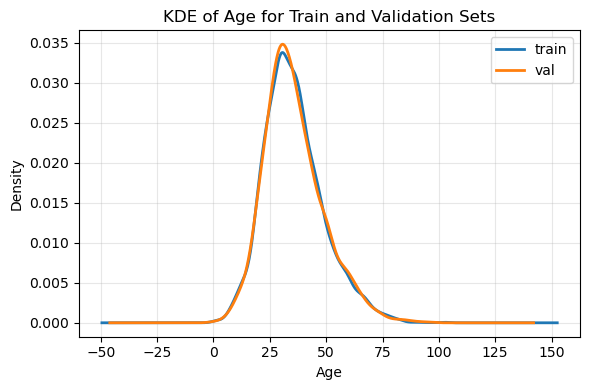

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# 训练集 age 的 KDE
train_df["age"].plot(kind="kde", label="train", linewidth=2)

# 验证集 age 的 KDE
val_df["age"].plot(kind="kde", label="val", linewidth=2)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("KDE of Age for Train and Validation Sets")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('./plots/age_kde_train_val.png', dpi=300)

plt.show()


In [51]:
smalldf.head(3)

,dob,photo_taken,full_path,gender,name,face_location,face_score,second_face_score,celeb_names,celeb_id,age
19520,719838,2001,60/nm0000160_rm318085120_1970-11-6_2001.jpg,1.0,[Ethan Hawke],"[[56.10910451345673, 56.10910451345673, 155.41...",4.328796,2.711690,[Valeria Bilello],6127,29
47607,710902,1990,33/nm0000333_rm2250881536_1946-5-20_1990.jpg,0.0,[Cher],"[[125.06924380321092, 273.92473636706404, 347....",4.791896,3.388407,NaN,3363,43
76567,716818,1995,48/nm0000648_rm1655216384_1962-7-31_1995.jpg,1.0,[Wesley Snipes],"[[249.366, 72.358, 291.824, 114.816]]",2.577274,1.913713,NaN,19883,32


In [52]:
REAL_ROOT = "/data/whb/DL_Pracs/Non-Param-Statistics/final-project/data/Wikiface/2/imdb_crop"

def patch_path(path: str) -> str:
    """
    原 path 类似：
      /data/.../reprod_project/36/nm0002536_xxx.jpg
    实际目录是：
      /data/.../data/Wikiface/2/imdb_crop/36/nm0002536_xxx.jpg
    这里取倒数第二级目录(36) + 文件名，拼到新的根目录下。
    """
    dirname, fname = os.path.split(path)          # dirname: .../reprod_project/36
    folder = os.path.basename(dirname)           # 36
    new_path = os.path.join(REAL_ROOT, folder, fname)
    return new_path

# 对 train_df 和 val_df 同样处理
train_df["full_path"] = train_df["full_path"].apply(patch_path)
val_df["full_path"]   = val_df["full_path"].apply(patch_path)

In [53]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from os import listdir
from os.path import isfile, join
from PIL import Image

import torch.optim as optim
from torch.autograd import grad
import time

import torch.utils.data as data_utils

from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize

from scipy.io import loadmat
from scipy.io import savemat

# -----------------------------
# 1. Dataset：从 dataframe 读图像 & age
# -----------------------------
class AgeImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        dataframe: 含有 'full_path' 和 'age' 两列
        transform: 图像预处理（用 CLIP 的 preprocess 或 _transform(nx)）
        """
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["full_path"]
        age = float(row["age"])

        # 读图并做预处理
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)      # [3, H, W] float tensor

        age_tensor = torch.tensor(age, dtype=torch.float32)
        return img, age_tensor


# -----------------------------
# 2. 构造 train / val Dataset + DataLoader
# -----------------------------
# 你已经有：
# device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
# model, preprocess = clip.load("RN50x4", device)
# features(net, x)  函数

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
try:
    from torchvision.transforms import InterpolationMode
    BICUBIC = InterpolationMode.BICUBIC
except ImportError:
    BICUBIC = Image.BICUBIC

def _convert_image_to_rgb(image):
    return image.convert("RGB")

def _transform(n_px):
    return Compose([
        Resize(n_px, interpolation=BICUBIC),
        CenterCrop(n_px),
        _convert_image_to_rgb,
        ToTensor(),
        Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
    ])
nx=144

# 这里用 CLIP 自带的 preprocess（或用你自己定义的 _transform(nx) 也可以）
train_dataset = AgeImageDataset(train_df, transform=_transform(nx))
val_dataset   = AgeImageDataset(val_df,   transform=_transform(nx))

batch_size = 64
num_workers = 4  # 如果 Windows 就设为 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [54]:
import clip
print(clip.available_models())
model, preprocess = clip.load('RN50x4', device)

relu = torch.nn.functional.relu
def features(net, x):
    x = x.type(net.conv1.weight.dtype)
    for conv, bn in [(net.conv1, net.bn1), (net.conv2, net.bn2), (net.conv3, net.bn3)]:
        x = relu(bn(conv(x)))
    x = net.avgpool(x)
    x = net.layer1(x)
    x = net.layer2(x)
    x = net.layer3(x)
    x = net.layer4(x)
    x=net.avgpool(x) 
    x=net.avgpool(x)
    return x

['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


In [55]:
from tqdm import tqdm
def generate_features(dataset, model, mode):
    labels = torch.empty(0).cpu()
    i = 0
    for images, labs in tqdm(DataLoader(dataset, batch_size=100), desc=mode):
            images = images.to(device)
            labs = labs.cpu()
            with torch.no_grad():
                f = features(model.visual,images) 
                # print(f"f.shape = {f.shape}")
                # print(f"f.dtype = {f.dtype}")
                f_sq = f.squeeze(3).squeeze(2)
                # print(f"after")
                # print(f"f_sq.shape = {f_sq.shape}")
                # print(f"f_sq.dtype = {f_sq.dtype}")
                # assert 1 == 2

            f_sq=f_sq.cpu()
            if i==0:
                d=f_sq.shape[1]
                feat = torch.empty(0, d).cpu()
            feat = torch.cat((feat,f_sq),dim=0)
            labels = torch.cat((labels , labs),dim=0)
            i = i+1
    return feat, labels

In [56]:
trainFeatures, trainAges = generate_features(train_dataset, model, mode='train')
# 验证集特征 & 标签（age）
valFeatures, valAges = generate_features(val_dataset, model, mode='val')

trFeatures = trainFeatures.float()             # (N_train, d)
trY        = trainAges.float()                # (N_train,)

valFeatures = valFeatures.float()             # (N_val, d)
valY        = valAges.float()                 # (N_val,)

d = trainFeatures.shape[1]
d

val: 100%|██████████| 20/20 [04:40<00:00, 14.02s/it]


2560

In [59]:
def to_cuda(X: torch.Tensor):
        device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
        return X.to(device)

In [80]:
import random
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # 可选：让 cuDNN 更可复现（会略微变慢）
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### OnlineFSA

In [99]:
import math
import time
import numpy as np
import torch

# 假定你已经有：
from onlineFSA import standardize_ra, onlineFSA, OLS_runningaves, running_aves, add_runningaves

def build_running_aves_from_tensor(X_t: torch.Tensor,
                                   y_t: torch.Tensor,
                                   batch_size: int = 256):
    """
    从 Torch Tensor (X_t, y_t) 构建 running averages，
    输出格式与原始 running_aves / add_runningaves 一致：
      {"n": n_sum, "Sx": Sx_sum, "Sy": Sy_sum, "Sxx": Sxx_sum, "Sxy": Sxy_sum, "Syy": Syy_sum}
    注意：内部会转成 numpy，在 CPU 上做。
    """
    # 先放到 CPU 上
    X_np = X_t.detach().cpu().numpy()
    y_np = y_t.detach().cpu().numpy().reshape(-1, 1)  # (n,1)

    n, p = X_np.shape
    num_batch = int(math.ceil(n / batch_size))

    # 初始化 running sums
    n_sum = 0
    Sx_sum = np.zeros((1, p), dtype=np.float64)
    Sy_sum = 0.0
    Sxx_sum = np.zeros((p, p), dtype=np.float64)
    Sxy_sum = np.zeros((p, 1), dtype=np.float64)
    Syy_sum = 0.0

    ra_sum = {
        "n": n_sum,
        "Sx": Sx_sum,
        "Sy": Sy_sum,
        "Sxx": Sxx_sum,
        "Sxy": Sxy_sum,
        "Syy": Syy_sum,
    }

    for i in range(num_batch):
        start = i * batch_size
        end = min((i + 1) * batch_size, n)
        if start >= end:
            break

        X_mb = X_np[start:end, :]       # (mb, p)
        y_mb = y_np[start:end, :]       # (mb, 1)

        # 复用你原有的 running_aves / add_runningaves（numpy 版本）
        ra_mb = running_aves(X_mb, y_mb)
        ra_sum = add_runningaves(ra_sum, ra_mb)

    # 检查样本数
    if ra_sum["n"] != n:
        print("[WARN] running_aves n mismatch:", ra_sum["n"], "!=", n)

    return ra_sum


def onlineFSA_wikiface_experiment(
    trFeatures: torch.Tensor,
    trY: torch.Tensor,
    valFeatures: torch.Tensor,
    valY: torch.Tensor,
    k: int = 100,            # 选多少特征
    eta: float = 0.01,
    mu: float = 10.0,
    lbd: float = 0.0,
    N_iter: int = 200,
    pre_train: int = 15,
    batch_size: int = 256,
    adaptive=True
):
    """
    在 Wikiface 的 (特征, age) 数据上跑一次 OnlineFSA 回归实验。

    输入:
      trFeatures : (N_train, d) 的 torch.Tensor
      trY        : (N_train,) 或 (N_train,1) 的 torch.Tensor (age)
      valFeatures: (N_val, d)
      valY       : (N_val,) 或 (N_val,1)

    返回:
      rmse_val   : 验证集上的 RMSE
      beta_hat   : (d,1) numpy array, FSA 回归系数（在标准化空间）
      sel        : 被选中的特征下标 (numpy array)
      time_cost  : FSA 求解时间（秒）
    """
    # ---- 0. 整形 ----
    if trY.dim() == 1:
        trY = trY.view(-1, 1)
    if valY.dim() == 1:
        valY = valY.view(-1, 1)

    n_train, p = trFeatures.shape
    assert trY.shape[0] == n_train, "训练特征和标签样本数不一致"

    # ---- 1. 从 Torch Tensor 构建 running averages ----
    ra_sum = build_running_aves_from_tensor(trFeatures, trY, batch_size=batch_size)

    # ---- 2. 标准化 running averages ----
    XX_normalize, XY_normalize, mu_x, mu_y, std_x = standardize_ra(ra_sum)
    # mu_x: (1,p), mu_y: 标量, std_x: (1,p)

    # ---- 3. OnlineFSA 求解 ----
    FSA_para = {
        "n": int(ra_sum["n"]),
        "k": int(k),
        "eta": float(eta),
        "mu": float(mu),
        "lbd": float(lbd),
        "N_iter": int(N_iter),
    }

    t_start = time.process_time()
    beta_sel, sel = onlineFSA(XX_normalize, XY_normalize, FSA_para, pre_train)
    t_end = time.process_time()
    time_cost = t_end - t_start

    sel = np.array(sel, dtype=int)          # 被选中的特征索引
    beta_sel = beta_sel.reshape(-1, 1)      # (len(sel),1)

    # ---- 4. 用 selected features 重构完整 beta_hat（在标准化空间）----
    beta_hat = np.zeros((p, 1), dtype=np.float64)
    beta_hat[sel] = beta_sel                # 其它特征系数为 0

    # ---- 5. 在验证集上评估 RMSE (age 回归) ----
    # 5.1 把 valFeatures 转成 numpy，并用训练集的 mu_x / std_x 标准化
    X_val_np = valFeatures.detach().cpu().numpy()
    Y_val_np = valY.detach().cpu().numpy()      # (N_val,1)
    n_val = X_val_np.shape[0]

    # 标准化：减均值 / 除以 std，与 standardize_ra 中保持一致
    X_val_center = X_val_np - np.ones((n_val, 1), dtype=np.float64).dot(mu_x)
    inv_sigma = 1.0 / std_x
    X_val_std = X_val_center * inv_sigma       # 广播 (n_val,p) * (1,p)

    # 5.2 预测
    Y_val_center = Y_val_np - mu_y * np.ones((n_val, 1), dtype=np.float64)
    Y_val_hat = X_val_std.dot(beta_hat)        # (n_val,1)

    err = Y_val_center - Y_val_hat
    rmse_val = float(np.sqrt(np.sum(err ** 2) / n_val))

    return rmse_val, beta_hat, sel, time_cost


In [ ]:
for k in tqdm([50, 100, 200, 500, 1000]):
    rmse_val, beta_hat, sel, time_cost = onlineFSA_wikiface_experiment(
        trFeatures=trFeatures,
        trY=trY,
        valFeatures=valFeatures,
        valY=valY,
        k=k,          # 你想选多少特征
        eta=0.01,
        mu=10.0,
        lbd=0.0,
        N_iter=200,
        pre_train=15,
        batch_size=256,  # 构建 running averages 时的 mini-batch 大小
        adaptive=True
    )

    print("Wikiface OnlineFSA (k={}): val RMSE = {:.4f}, time = {:.4f}s, selected |S| = {}".format(
        k, rmse_val, time_cost, len(sel)
    ))

    # ===== 计算验证集上的 R^2 =====
    # 1. 取出验证集标签为 numpy
    if isinstance(valY, torch.Tensor):
        y_val = valY.detach().cpu().numpy().reshape(-1)
    else:
        y_val = np.asarray(valY).reshape(-1)

    n_val = y_val.shape[0]

    # 2. SSE = RMSE^2 * n
    SSE = (rmse_val ** 2) * n_val

    # 3. SST = sum((y - y_mean)^2)
    y_mean = y_val.mean()
    SST = np.sum((y_val - y_mean) ** 2)

    # 4. R^2
    R2 = 1.0 - SSE / SST

    print("Wikiface OnlineFSA: val R^2 = {:.4f}".format(R2))

    print("##" * 10)

# rmse_val, beta_hat, sel, time_cost = onlineFSA_wikiface_experiment(
#     trFeatures=trFeatures,
#     trY=trY,
#     valFeatures=valFeatures,
#     valY=valY,
#     k=100,          # 你想选多少特征
#     eta=0.01,
#     mu=10.0,
#     lbd=0.0,
#     N_iter=200,
#     pre_train=15,
#     batch_size=256  # 构建 running averages 时的 mini-batch 大小
# )

# print("Wikiface OnlineFSA: val RMSE = {:.4f}, time = {:.4f}s, selected |S| = {}".format(
#     rmse_val, time_cost, len(sel)
# ))


 20%|██        | 1/5 [00:07<00:28,  7.08s/it]

Wikiface OnlineFSA (k=50): val RMSE = 10.3853, time = 29.6709s, selected |S| = 50
Wikiface OnlineFSA: val R^2 = 0.3776
####################


 40%|████      | 2/5 [00:13<00:20,  6.85s/it]

Wikiface OnlineFSA (k=100): val RMSE = 10.3928, time = 39.2036s, selected |S| = 100
Wikiface OnlineFSA: val R^2 = 0.3767
####################


 60%|██████    | 3/5 [00:20<00:13,  6.81s/it]

Wikiface OnlineFSA (k=200): val RMSE = 10.4426, time = 45.5417s, selected |S| = 200
Wikiface OnlineFSA: val R^2 = 0.3708
####################


 80%|████████  | 4/5 [00:28<00:07,  7.35s/it]

Wikiface OnlineFSA (k=500): val RMSE = 10.5013, time = 73.2287s, selected |S| = 500
Wikiface OnlineFSA: val R^2 = 0.3637
####################


100%|██████████| 5/5 [00:40<00:00,  8.14s/it]

Wikiface OnlineFSA (k=1000): val RMSE = 10.5377, time = 123.7462s, selected |S| = 1000
Wikiface OnlineFSA: val R^2 = 0.3592
####################


### OnlineFSA w.o. Adaptation

In [100]:
for k in tqdm([50, 100, 200, 500, 1000]):
    rmse_val, beta_hat, sel, time_cost = onlineFSA_wikiface_experiment(
        trFeatures=trFeatures,
        trY=trY,
        valFeatures=valFeatures,
        valY=valY,
        k=k,          # 你想选多少特征
        eta=0.01,
        mu=10.0,
        lbd=0.0,
        N_iter=200,
        pre_train=15,
        batch_size=256,  # 构建 running averages 时的 mini-batch 大小
        adaptive=True
    )

    print("Wikiface OnlineFSA wo adapt (k={}): val RMSE = {:.4f}, time = {:.4f}s, selected |S| = {}".format(
        k, rmse_val, time_cost, len(sel)
    ))

    # ===== 计算验证集上的 R^2 =====
    # 1. 取出验证集标签为 numpy
    if isinstance(valY, torch.Tensor):
        y_val = valY.detach().cpu().numpy().reshape(-1)
    else:
        y_val = np.asarray(valY).reshape(-1)

    n_val = y_val.shape[0]

    # 2. SSE = RMSE^2 * n
    SSE = (rmse_val ** 2) * n_val

    # 3. SST = sum((y - y_mean)^2)
    y_mean = y_val.mean()
    SST = np.sum((y_val - y_mean) ** 2)

    # 4. R^2
    R2 = 1.0 - SSE / SST

    print("Wikiface OnlineFSA wo adapt: val R^2 = {:.4f}".format(R2))

    print("##" * 10)

 20%|██        | 1/5 [00:07<00:28,  7.04s/it]

Wikiface OnlineFSA wo adapt (k=50): val RMSE = 10.3853, time = 49.1337s, selected |S| = 50
Wikiface OnlineFSA wo adapt: val R^2 = 0.3776
####################


 40%|████      | 2/5 [00:13<00:19,  6.49s/it]

Wikiface OnlineFSA wo adapt (k=100): val RMSE = 10.3928, time = 33.3707s, selected |S| = 100
Wikiface OnlineFSA wo adapt: val R^2 = 0.3767
####################


 60%|██████    | 3/5 [00:20<00:13,  6.95s/it]

Wikiface OnlineFSA wo adapt (k=200): val RMSE = 10.4426, time = 51.0071s, selected |S| = 200
Wikiface OnlineFSA wo adapt: val R^2 = 0.3708
####################


 80%|████████  | 4/5 [00:29<00:07,  7.54s/it]

Wikiface OnlineFSA wo adapt (k=500): val RMSE = 10.5013, time = 63.1304s, selected |S| = 500
Wikiface OnlineFSA wo adapt: val R^2 = 0.3637
####################


100%|██████████| 5/5 [00:40<00:00,  8.17s/it]

Wikiface OnlineFSA wo adapt (k=1000): val RMSE = 10.5377, time = 132.7920s, selected |S| = 1000
Wikiface OnlineFSA wo adapt: val R^2 = 0.3592
####################


In [73]:
import numpy as np
import time
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from Lassofeaturesel import Lasso_feature_sel

import torch  # 新增：需要判断/转换 torch.Tensor


def offline_lasso_experiment(
    X_train, y_train,
    X_val, y_val,
    lbd_para,   # 形如 {"start": -10, "end": 10}
    k          # 目标选择特征个数
):
    """
    仿照 Lasso_num_exp 的 offline Lasso 实验过程，但用的是给定的
    (X_train, y_train, X_val, y_val)，不再自己生成数据。
    """

    # ====== 0. 统一转成 numpy（防止 torch.Tensor 尤其是 CUDA tensor 直接喂给 numpy/sklearn）======
    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        # 已经是 numpy 或 list 等，交给 np.asarray 处理
        return np.asarray(x)

    X_train = to_numpy(X_train)
    y_train = to_numpy(y_train)
    X_val   = to_numpy(X_val)
    y_val   = to_numpy(y_val)

    # ---------- 1. 标准化 X，中心化 y ----------
    # X: 标准化；y: 仅减训练集均值（不缩放）
    X_scaler = preprocessing.StandardScaler().fit(X_train)
    X_tr_scale = X_scaler.transform(X_train)
    X_val_scale = X_scaler.transform(X_val)

    y_train = y_train.reshape(-1)
    y_val = y_val.reshape(-1)

    y_mean = np.mean(y_train)
    y_tr_center = y_train - y_mean
    # 如果你需要在“中心化域”上看验证误差可以用 y_val_center，这里后面没用到也没关系
    # y_val_center = y_val - y_mean  

    # ---------- 2. Lasso 特征选择（用你的 Lasso_feature_sel） ----------
    t_start = time.process_time()
    # 注意：Lasso_feature_sel 返回的是 (beta_sel_index, lbd_mid)
    lasso_sel_index, lbd_sel = Lasso_feature_sel(
        X_tr_scale,
        y_tr_center,
        lbd_para,
        k
    )
    t_end = time.process_time()
    time_cost = t_end - t_start

    # 极端情况：没选到任何特征
    if lasso_sel_index is None or len(lasso_sel_index) == 0:
        return {
            "lambda_sel": lbd_sel,
            "sel_index": np.array([], dtype=int),
            "rmse_val": np.nan,
            "r2_val": np.nan,
            "time_cost": time_cost,
            "n_selected": 0,
        }

    # ---------- 3. 在选中特征上 refit OLS ----------
    X_tr_sel = X_tr_scale[:, lasso_sel_index]
    ols = LinearRegression(fit_intercept=False)
    ols.fit(X_tr_sel, y_tr_center)
    beta_hat_ols = ols.coef_  # shape: (#sel,)

    # ---------- 4. 在验证集上评估 ----------
    X_val_sel = X_val_scale[:, lasso_sel_index]
    # 先得到中心化域上的预测，再加回训练集均值，回到原始尺度
    y_val_pred_center = X_val_sel.dot(beta_hat_ols)
    y_val_pred = y_val_pred_center + y_mean

    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2_val = r2_score(y_val, y_val_pred)

    return {
        "lambda_sel": lbd_sel,
        "sel_index": lasso_sel_index,
        "rmse_val": rmse_val,
        "r2_val": r2_val,
        "time_cost": time_cost,
        "n_selected": len(lasso_sel_index),
    }


In [81]:
# 这里默认 offline_lasso_experiment 已经按你给的版本定义好了
# from your_module import offline_lasso_experiment

lbd_para = {"start": -10, "end": 10}
k = 100

num_runs = 5
seeds = [2026 + i for i in range(num_runs)]   # 也可以改成 [0,1,2,3,4]
all_results = []

for s in tqdm(seeds):
    print(f"\n===== Run with seed {s} =====")
    set_seed(s)

    res = offline_lasso_experiment(
        trFeatures, trY,
        valFeatures, valY,
        lbd_para=lbd_para,
        k=k
    )

    # 把 seed 一起存进去，方便后面统计和打印
    res["seed"] = s
    all_results.append(res)

    print("λ*        =", res["lambda_sel"])
    print("selected |S| =", res["n_selected"])
    print("val RMSE  =", res["rmse_val"])
    print("val R^2   =", res["r2_val"])
    print("time_cost =", res["time_cost"])



===== Run with seed 2026 =====
100
λ*        = 0.3134954203426171
selected |S| = 100
val RMSE  = 10.351994
val R^2   = 0.3816233678783508
time_cost = 76.541055417998

===== Run with seed 2027 =====
100
λ*        = 0.3134954203426171
selected |S| = 100
val RMSE  = 10.351994
val R^2   = 0.3816233678783508
time_cost = 76.31250763400021

===== Run with seed 2028 =====
100
λ*        = 0.3134954203426171
selected |S| = 100
val RMSE  = 10.351994
val R^2   = 0.3816233678783508
time_cost = 77.9649160029985

===== Run with seed 2029 =====
100
λ*        = 0.3134954203426171
selected |S| = 100
val RMSE  = 10.351994
val R^2   = 0.3816233678783508
time_cost = 76.99647980699956

===== Run with seed 2030 =====
100
λ*        = 0.3134954203426171
selected |S| = 100
val RMSE  = 10.351994
val R^2   = 0.3816233678783508
time_cost = 79.21955112200158


In [83]:
# =========== 汇总 5 次结果 ===========
print("\n===== Summary over 5 seeds =====")
for r in all_results:
    print(
        f"Seed {r['seed']}: "
        f"RMSE={r['rmse_val']:.4f}, "
        f"R^2={r['r2_val']:.4f}, "
        f"time={r['time_cost']:.4f}s, "
        f"|S|={r['n_selected']}"
    )

# 统计 RMSE 和 R^2 的均值与标准差
rmse_arr = np.array([r["rmse_val"] for r in all_results], dtype=float)
r2_arr   = np.array([r["r2_val"]   for r in all_results], dtype=float)
time_arr = np.array([r["time_cost"] for r in all_results], dtype=float)

rmse_mean, rmse_std = rmse_arr.mean(), rmse_arr.std(ddof=1)
r2_mean,   r2_std   = r2_arr.mean(),   r2_arr.std(ddof=1)
time_mean, time_std = time_arr.mean(), time_arr.std(ddof=1)

print("\n===== Aggregate Statistics (5 runs) =====")
print(f"RMSE: mean={rmse_mean:.4f}, std={rmse_std:.4f}")
print(f"R^2 : mean={r2_mean:.4f}, std={r2_std:.4f}")
print(f"time: mean={time_mean:.4f}s, std={time_std:.4f}s")



===== Summary over 5 seeds =====
Seed 2026: RMSE=10.3520, R^2=0.3816, time=76.5411s, |S|=100
Seed 2027: RMSE=10.3520, R^2=0.3816, time=76.3125s, |S|=100
Seed 2028: RMSE=10.3520, R^2=0.3816, time=77.9649s, |S|=100
Seed 2029: RMSE=10.3520, R^2=0.3816, time=76.9965s, |S|=100
Seed 2030: RMSE=10.3520, R^2=0.3816, time=79.2196s, |S|=100

===== Aggregate Statistics (5 runs) =====
RMSE: mean=10.3520, std=0.0000
R^2 : mean=0.3816, std=0.0000
time: mean=77.4069s, std=1.1951s


In [88]:
import numpy as np
import time
import torch

from sklearn import preprocessing
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score


def offline_sk_lasso_experiment(
    X_train, y_train,
    X_val, y_val,
    lbd_para,   # 形如 {"start": -10, "end": 10}
    k,          # 目标选择特征个数
    n_lbd=60    # 在区间内采样多少个 lambda 候选
):
    """
    使用 sklearn 官方 Lasso，做一次完整的 offline 回归实验。

    流程：
      1. 将可能的 torch.Tensor 输入统一转换为 numpy；
      2. 对 X 做标准化（StandardScaler），y 仅做中心化（减训练集均值）；
      3. 在 exp(start) ~ exp(end) 之间构造若干 alpha（lambda），
         对每个 alpha 拟合 Lasso，看非零特征个数与目标 k 的差距；
      4. 选择 |#nonzero - k| 最小的 alpha 作为 lambda_sel；
      5. 在该 alpha 下重新训练 Lasso，得到最终模型；
      6. 在验证集上用该 Lasso 模型预测，计算 RMSE 和 R²。

    返回：
      {
        "lambda_sel": 选中的 alpha,
        "sel_index":  非零特征下标 (np.ndarray),
        "rmse_val":   验证集 RMSE,
        "r2_val":     验证集 R^2,
        "time_cost":  Lasso 选择特征 + 训练耗时（秒）,
        "n_selected": 选中特征个数,
      }
    """

    # ====== 0. 统一转成 numpy（兼容 torch.Tensor / CUDA tensor）======
    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    X_train = to_numpy(X_train)
    y_train = to_numpy(y_train)
    X_val   = to_numpy(X_val)
    y_val   = to_numpy(y_val)

    # ---------- 1. 标准化 X，中心化 y ----------
    X_scaler = preprocessing.StandardScaler().fit(X_train)
    X_tr_scale = X_scaler.transform(X_train)
    X_val_scale = X_scaler.transform(X_val)

    y_train = y_train.reshape(-1)
    y_val = y_val.reshape(-1)

    y_mean = np.mean(y_train)
    y_tr_center = y_train - y_mean

    # ---------- 2. 构造 lambda（alpha）候选网格 ----------
    start = float(lbd_para["start"])
    end   = float(lbd_para["end"])
    lambda_grid = np.exp(np.linspace(start, end, n_lbd))  # e^{start} ~ e^{end}

    # ---------- 3. 在网格上搜索“非零特征数最接近 k 的 alpha” ----------
    t_start = time.process_time()

    best = None  # (gap, alpha, coef, sel_idx)
    for alpha in lambda_grid:
        model = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
        model.fit(X_tr_scale, y_tr_center)
        beta = model.coef_
        sel_idx = np.flatnonzero(beta)
        gap = abs(len(sel_idx) - k)

        if best is None or gap < best[0]:
            best = (gap, alpha, beta, sel_idx)

    gap_best, alpha_sel, beta_sel, sel_index = best
    time_cost = time.process_time() - t_start

    # 防御：万一没选到特征
    if sel_index is None or len(sel_index) == 0:
        return {
            "lambda_sel": alpha_sel,
            "sel_index": np.array([], dtype=int),
            "rmse_val": np.nan,
            "r2_val": np.nan,
            "time_cost": time_cost,
            "n_selected": 0,
        }

    # ---------- 4. 在选中的 alpha 下重新训练 Lasso（官方版本） ----------
    lasso_best = Lasso(alpha=alpha_sel, fit_intercept=False, max_iter=1000)
    lasso_best.fit(X_tr_scale, y_tr_center)
    beta_final = lasso_best.coef_
    sel_index  = np.flatnonzero(beta_final)  # 最终非零特征

    # ---------- 5. 在验证集上评估 ----------
    y_val_pred_center = lasso_best.predict(X_val_scale)
    y_val_pred = y_val_pred_center + y_mean

    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2_val = r2_score(y_val, y_val_pred)

    return {
        "lambda_sel": alpha_sel,
        "sel_index": sel_index,
        "rmse_val": rmse_val,
        "r2_val": r2_val,
        "time_cost": time_cost,
        "n_selected": len(sel_index),
    }


In [89]:
# 假设你已有：trFeatures, trY, valFeatures, valY
# lbd_para = {"start": -10, "end": 10}
# k = 100

lbd_para = {"start": -10, "end": 10}
k = 100

all_results = []

n_runs = 5
for run in range(n_runs):
    print(f"\n===== Run {run+1}/{n_runs} (sklearn Lasso) =====")

    res = offline_sk_lasso_experiment(
        trFeatures, trY,
        valFeatures, valY,
        lbd_para=lbd_para,
        k=k
    )

    print("λ* =", res["lambda_sel"])
    print("selected |S| =", res["n_selected"])
    print("val RMSE =", res["rmse_val"])
    print("val R^2  =", res["r2_val"])
    print("time_cost =", res["time_cost"])

    res["run"] = run
    all_results.append(res)

# ====== 汇总 5 次的 RMSE / R^2 统计量 ======
rmse_list = np.array([r["rmse_val"] for r in all_results], dtype=float)
r2_list   = np.array([r["r2_val"]   for r in all_results], dtype=float)

rmse_mean = np.nanmean(rmse_list)
rmse_std  = np.nanstd(rmse_list, ddof=1)  # 样本标准差
r2_mean   = np.nanmean(r2_list)
r2_std    = np.nanstd(r2_list, ddof=1)

print("\n===== Summary over 5 runs (sklearn Lasso) =====")




===== Run 1/5 (sklearn Lasso) =====


/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.590e+05, tolerance: 1.390e+02
  model = cd_fast.enet_coordinate_descent(
/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.541e+05, tolerance: 1.390e+02
  model = cd_fast.enet_coordinate_descent(
/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

λ* = 0.3053060148585694
selected |S| = 109
val RMSE = 10.258651
val R^2  = 0.39272472605330844
time_cost = 35217.744404733

===== Run 2/5 (sklearn Lasso) =====


/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.590e+05, tolerance: 1.390e+02
  model = cd_fast.enet_coordinate_descent(
/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.541e+05, tolerance: 1.390e+02
  model = cd_fast.enet_coordinate_descent(
/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

KeyboardInterrupt: 

In [ ]:
for r in all_results:
    print(
        f"Run {r['run']}: "
        f"RMSE={r['rmse_val']:.4f}, "
        f"R^2={r['r2_val']:.4f}, "
        f"|S|={r['n_selected']}"
    )

print("\n[Stats] RMSE mean  = {:.4f}, std = {:.4f}".format(rmse_mean, rmse_std))
print("[Stats] R^2   mean = {:.4f}, std = {:.4f}".format(r2_mean, r2_std))

In [82]:
# lbd_para = {"start": -10, "end": 10}
# k = 100

# res = offline_lasso_experiment(
#     trFeatures, trY,
#     valFeatures, valY,
#     lbd_para=lbd_para,
#     k=k
# )

# print("λ* =", res["lambda_sel"])
# print("selected |S| =", res["n_selected"])
# print("val RMSE =", res["rmse_val"])
# print("val R^2  =", res["r2_val"])
# print("time_cost =", res["time_cost"])


In [ ]:
# # 构造 lambda 候选（和你原来 offline 实验可以保持同一个范围）
# lambda_grid = np.logspace(-4, 0, 20)   # 例如 [1e-4, ..., 1]

# rmse_lasso, lbd_sel, sel_index, time_cost = onlineLasso_wikiface_experiment(
#     trFeatures=trFeatures,
#     trY=trY,
#     valFeatures=valFeatures,
#     valY=valY,
#     lambda_grid=lambda_grid,
#     k_target=None,          # 如果想用 "closest_k"，比如 = 100
#     selection_mode="cv",    # 或 "closest_k"
#     n_splits=5
# )

# print(f"[online Lasso] val RMSE={rmse_lasso:.4f}, "
#       f"lambda={lbd_sel:.4e}, |S|={len(sel_index)}, time={time_cost:.4f}s")


/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.675e+06, tolerance: 1.657e+03
  model = cd_fast.enet_coordinate_descent(
/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.100e+06, tolerance: 1.659e+03
  model = cd_fast.enet_coordinate_descent(
/home/whb/miniconda3/envs/retro/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

### MLP

In [64]:
# 先封装成torch.tensor
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 保证是 numpy
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x

X_train_np = to_numpy(trFeatures)
y_train_np = to_numpy(trY).reshape(-1, 1)       # (N, 1)

X_val_np   = to_numpy(valFeatures)
y_val_np   = to_numpy(valY).reshape(-1, 1)

# 转成 tensor
X_train = torch.from_numpy(X_train_np).float()
y_train = torch.from_numpy(y_train_np).float()

X_val   = torch.from_numpy(X_val_np).float()
y_val   = torch.from_numpy(y_val_np).float()

# Dataset & DataLoader
batch_size = 128

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


In [65]:
import torch.nn as nn
import torch.nn.functional as F

class TwoLayerMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)   # 回归输出 1 维

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x   # shape: (batch_size, 1)

input_dim = X_train.shape[1]
model = TwoLayerMLP(input_dim=input_dim, hidden_dim=512).to(device)


In [84]:

from sklearn.metrics import r2_score

# 假设你已经有：
# - train_loader, val_loader
# - train_ds, val_ds
# - device
# - MyMLP 这个模型类，或者你自己的 model 定义函数



def run_one_seed(seed, MyMLP, input_dim, hidden_dim=256):
    """
    在给定 seed 下训练一次 MLP，返回该次实验的最好指标
    """
    print(f"\n========== Seed {seed} ==========")
    set_seed(seed)

    # 重新初始化模型和优化器（很关键，否则不会是独立实验）
    model = MyMLP(input_dim, hidden_dim).to(device)  # 举例：两层 MLP 输出 1 维
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    num_epochs = 500

    # ==== Early Stopping 参数 ====
    patience = 20                 # 连续多少个 epoch 没提升就停
    best_val_loss = float('inf')  # 当前最优验证损失
    best_state_dict = None        # 存储最优模型参数
    no_improve_epochs = 0         # 已连续无提升的 epoch 数

    best_rmse = None
    best_r2   = None

    for epoch in range(1, num_epochs + 1):
        # ---------- train ----------
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)           # (batch, 1)
            loss = criterion(preds, yb) # MSE
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * xb.size(0)

        train_loss = train_loss / len(train_ds)

        # ---------- validate ----------
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item() * xb.size(0)

                all_preds.append(preds.cpu())
                all_targets.append(yb.cpu())

        val_loss = val_loss / len(val_ds)

        # 计算 RMSE & R²（在 CPU 上用 numpy）
        all_preds = torch.cat(all_preds, dim=0).numpy().reshape(-1)
        all_targets = torch.cat(all_targets, dim=0).numpy().reshape(-1)

        rmse_val = math.sqrt(((all_preds - all_targets) ** 2).mean())
        r2_val = r2_score(all_targets, all_preds)

        print(
            f"Epoch [{epoch}/{num_epochs}] "
            f"train MSE={train_loss:.4f}, val MSE={val_loss:.4f}, "
            f"val RMSE={rmse_val:.4f}, val R^2={r2_val:.4f}"
        )

        # ---------- Early Stopping 逻辑 ----------
        if val_loss < best_val_loss - 1e-6:  # 可以加一个很小的阈值防止浮动
            best_val_loss = val_loss
            best_rmse = rmse_val
            best_r2 = r2_val
            best_state_dict = model.state_dict()  # 保存当前最优参数
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        if no_improve_epochs >= patience:
            print(f"Early stopping triggered at epoch {epoch}!")
            break

    # 训练结束后，恢复到验证集上表现最好的那一版参数
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        print(f"Loaded best model with val MSE={best_val_loss:.4f}, "
              f"RMSE={best_rmse:.4f}, R^2={best_r2:.4f}")

    # 返回该 seed 下最优结果
    return {
        "seed": seed,
        "best_val_MSE": best_val_loss,
        "best_val_RMSE": best_rmse,
        "best_val_R2": best_r2,
        "state_dict": best_state_dict,   # 如果你之后想用
    }


# =========================
# 主循环：在不同 seed 下跑 5 次
# =========================
seeds = [i + 2026 for i in range(5)]
all_results = []

# 假设输入维度就是特征维度：
input_dim = next(iter(train_loader))[0].shape[1]

for s in seeds:
    st = time.time()
    res = run_one_seed(seed=s, MyMLP=TwoLayerMLP, input_dim=input_dim, hidden_dim=256)
    ed = time.time()
    all_results.append(res)

ed-st



========== Seed 2026 ==========
Epoch [1/500] train MSE=292.5436, val MSE=138.6703, val RMSE=11.7758, val R^2=0.1998
Epoch [2/500] train MSE=127.4060, val MSE=112.9796, val RMSE=10.6292, val R^2=0.3481
Epoch [3/500] train MSE=112.8090, val MSE=109.5868, val RMSE=10.4684, val R^2=0.3676
Epoch [4/500] train MSE=108.9458, val MSE=107.5558, val RMSE=10.3709, val R^2=0.3794
Epoch [5/500] train MSE=106.3486, val MSE=107.0868, val RMSE=10.3483, val R^2=0.3821
Epoch [6/500] train MSE=104.6217, val MSE=106.0797, val RMSE=10.2995, val R^2=0.3879
Epoch [7/500] train MSE=102.6233, val MSE=106.2875, val RMSE=10.3096, val R^2=0.3867
Epoch [8/500] train MSE=101.3537, val MSE=105.8581, val RMSE=10.2887, val R^2=0.3892
Epoch [9/500] train MSE=100.0745, val MSE=105.9396, val RMSE=10.2927, val R^2=0.3887
Epoch [10/500] train MSE=98.5109, val MSE=106.1647, val RMSE=10.3036, val R^2=0.3874
Epoch [11/500] train MSE=97.7278, val MSE=107.7715, val RMSE=10.3813, val R^2=0.3781
Epoch [12/500] train MSE=96.8012

4.7332658767700195

In [78]:
print("\n===== Summary over 5 seeds =====")
for r in all_results:
    print(
        f"Seed {r['seed']}: "
        f"MSE={r['best_val_MSE']:.4f}, "
        f"RMSE={r['best_val_RMSE']:.4f}, "
        f"R^2={r['best_val_R2']:.4f}"
    )



===== Summary over 5 seeds =====
Seed 2026: MSE=105.8581, RMSE=10.2887, R^2=0.3892
Seed 2027: MSE=105.4151, RMSE=10.2672, R^2=0.3917
Seed 2028: MSE=105.7178, RMSE=10.2819, R^2=0.3900
Seed 2029: MSE=105.7485, RMSE=10.2834, R^2=0.3898
Seed 2030: MSE=105.5641, RMSE=10.2744, R^2=0.3909


In [79]:
# ---- 统计 RMSE 的均值和标准差 ----
rmse_list = [r["best_val_RMSE"] for r in all_results if r["best_val_RMSE"] is not None]

rmse_mean = np.mean(rmse_list)
rmse_std  = np.std(rmse_list, ddof=1)   # 样本标准差

print("\n===== RMSE over 5 seeds =====")
print(f"Mean RMSE = {rmse_mean:.4f}")
print(f"Std  RMSE = {rmse_std:.4f}")


===== RMSE over 5 seeds =====
Mean RMSE = 10.2791
Std  RMSE = 0.0084


In [85]:
torch.cuda.empty_cache()